### **Soft Actor-Critic (SAC) on LunarLander-Continuous**

A clean, vanilla implementation of **SAC** for the `LunarLanderContinuous-v2` environment.

The goal is clarity, not benchmark performance. The code follows the same flow as the algorithm description on paper — no hidden tricks, no auto-tuned hyperparameters, no extra stability hacks.

#### **What SAC is**

SAC is an **off-policy actor-critic** method for **continuous action spaces**, like TD3. The defining difference is the **maximum-entropy objective**:

$$
J(\pi) = \mathbb{E}\left[\sum_t r(s_t, a_t) + \alpha\, \mathcal{H}(\pi(\cdot \mid s_t))\right]
$$

The agent is rewarded not just for collecting reward, but for keeping its action distribution **broad** (high entropy). This encourages exploration without needing external noise schedules.

#### **SAC vs. TD3 in one table**

| | TD3 | SAC |
|---|---|---|
| Policy | Deterministic $\mu(s)$ | Stochastic $\pi(a \mid s)$ — squashed Gaussian |
| Exploration | External action noise | Built-in policy entropy |
| Critic target | $r + \gamma \cdot \min(Q_1', Q_2')(s', \tilde a)$ | $r + \gamma \cdot \big[\min(Q_1', Q_2')(s', a') - \alpha \log \pi(a' \mid s')\big]$ |
| Actor loss | $-\, Q_1(s, \mu(s))$ | $\alpha \log \pi(a \mid s) - \min(Q_1, Q_2)(s, a)$ |
| Target smoothing trick | Noise added to $\tilde a$ | Not needed — entropy already smooths things |
| Delayed actor updates | Yes (every $d$ steps) | Not needed — typically updates every step |

Twin critics and soft target updates are shared. The entropy term is what does the heavy lifting in SAC.

#### **What we'll build**

1. A `ReplayBuffer` (just a NumPy ring buffer).
2. A `GaussianPolicy` — outputs a squashed Gaussian over actions.
3. A `QCritic` — standard MLP $Q(s, a)$. We instantiate two of them.
4. One training loop with the SAC update written inline so you can read it top-to-bottom.

No tricks beyond what's in the original SAC paper: **fixed $\alpha$**, no auto-tuning, no layer norm, no n-step returns.


In [1]:
import math
import random
from collections import deque
import os

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gymnasium as gym
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


Using device: cuda


#### **LunarLander Continuous environment**

`LunarLander Continuous` gives us:

- **Observation:** 8-dim vector (position, velocity, angle, angular velocity, two contact flags).
- **Action:** 2-dim continuous vector in $[-1, 1]^2$ — main engine throttle and lateral engine throttle.
- **Reward:** positive for landing on the pad, negative for crashing or using fuel.
- **Episode ends:** lander touches down, crashes, or flies off-screen.

The action range $[-1, 1]^2$ matches exactly what our `tanh`-squashed policy will output, so no rescaling is needed.


In [2]:
env = gym.make("LunarLander-v3", continuous=True)

obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.shape[0]
act_low  = float(env.action_space.low[0])
act_high = float(env.action_space.high[0])

print(f"Observation dim: {obs_dim}")
print(f"Action dim:      {act_dim}")
print(f"Action range:    [{act_low}, {act_high}]")


Observation dim: 8
Action dim:      2
Action range:    [-1.0, 1.0]


/home/jaume/_DEVELOPMENT/ML/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


#### **Hyperparameters**

Standard SAC defaults. The only one worth flagging is **`alpha = 0.2`** — the entropy coefficient. In "vanilla" SAC this is a fixed scalar. (The version of SAC with auto-tuned $\alpha$ is the most common in practice, but it's an extra trick we're deliberately leaving out for clarity.)


In [3]:
# --- Algorithm hyperparameters ---
GAMMA       = 0.99      # discount factor
TAU         = 0.005     # soft-update rate for target networks
ALPHA       = 0.2       # entropy coefficient (fixed; this is "vanilla" SAC)
LR          = 3e-4      # learning rate for actor and critics
BATCH_SIZE  = 256
BUFFER_SIZE = 1_000_000
ROLLING_WINDOW = 100
solved_threshold = 200

# --- Training schedule ---
TOTAL_STEPS  = 500_000   # total environment steps. Bump to ~250k for better results.
START_STEPS  = 1_000     # random actions for first N steps (uniform exploration)
UPDATE_AFTER = 1_000     # don't start updating networks until buffer has this much
UPDATES_PER_STEP = 1     # one gradient step per env step
MAX_STEPS_PER_EPSISODE = 1000

#### **Replay buffer**

Vanilla SAC is **off-policy** — it learns from past experience stored in a replay buffer. Each transition is $(s, a, r, s', \text{done})$.

We use plain NumPy arrays as a fixed-size ring buffer.


In [4]:
class ReplayBuffer:
    def __init__(self, capacity, obs_dim, act_dim):
        self.capacity = capacity
        self.ptr = 0
        self.size = 0
        self.obs      = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions  = np.zeros((capacity, act_dim), dtype=np.float32)
        self.rewards  = np.zeros((capacity, 1),       dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.dones    = np.zeros((capacity, 1),       dtype=np.float32)

    def add(self, s, a, r, s_next, done):
        i = self.ptr
        self.obs[i]      = s
        self.actions[i]  = a
        self.rewards[i]  = r
        self.next_obs[i] = s_next
        self.dones[i]    = done
        self.ptr  = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (
            torch.as_tensor(self.obs[idx],      device=device),
            torch.as_tensor(self.actions[idx],  device=device),
            torch.as_tensor(self.rewards[idx],  device=device),
            torch.as_tensor(self.next_obs[idx], device=device),
            torch.as_tensor(self.dones[idx],    device=device),
        )

    def __len__(self):
        return self.size


### **The stochastic policy (squashed Gaussian)**

The actor outputs the parameters of a Gaussian over a "pre-squashed" action $u$, then squashes it through $\tanh$ to land in $[-1, 1]$:

$$
\mu, \log\sigma = f_\theta(s),\quad u \sim \mathcal{N}(\mu, \sigma^2),\quad a = \tanh(u)
$$

Two important details:

**Reparameterization trick.** We sample $u = \mu + \sigma \cdot \epsilon$ with $\epsilon \sim \mathcal{N}(0, 1)$ so gradients flow through $\mu$ and $\sigma$. This is what lets us backprop the critic's gradient into the actor.

**Tanh log-prob correction.** Because $a = \tanh(u)$ is a change of variables, the log-density of $a$ picks up a Jacobian term:

$$
\log \pi(a \mid s) = \log \mathcal{N}(u \mid \mu, \sigma^2) - \sum_i \log(1 - \tanh(u_i)^2)
$$

In practice we use a numerically stable form of the correction.


In [5]:
LOG_STD_MIN = -20.0
LOG_STD_MAX = 2.0

class GaussianPolicy(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden,  hidden), nn.ReLU(),
        )
        self.mean_head    = nn.Linear(hidden, act_dim)
        self.log_std_head = nn.Linear(hidden, act_dim)

    def forward(self, obs):
        h = self.net(obs)
        mean    = self.mean_head(h)
        log_std = self.log_std_head(h).clamp(LOG_STD_MIN, LOG_STD_MAX)
        return mean, log_std

    def sample(self, obs):
        """
        Returns (action, log_prob). Uses the reparameterization trick so
        gradients flow into mean / log_std.
        """
        mean, log_std = self.forward(obs)
        std = log_std.exp()

        # Reparameterized sample u = mean + std * eps, eps ~ N(0, 1)
        normal = torch.distributions.Normal(mean, std)
        u = normal.rsample()
        a = torch.tanh(u)

        # log_prob of u under the Gaussian, then tanh correction.
        # The +1e-6 inside the log keeps things finite when a is at ±1.
        log_prob = normal.log_prob(u) - torch.log(1 - a.pow(2) + 1e-6)
        log_prob = log_prob.sum(dim=-1, keepdim=True)

        return a, log_prob


#### **The critic networks**

Each critic is a standard MLP that takes $(s, a)$ concatenated and returns a scalar $Q(s, a)$. We'll instantiate **two** of them and use `min(Q_1, Q_2)` to fight overestimation bias — exactly the same idea as in TD3.

Each critic also gets a **target network** that's a slow-moving copy of its weights (Polyak / soft updates).


In [6]:
class QCritic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim + act_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, obs, action):
        x = torch.cat([obs, action], dim=-1)
        return self.net(x)


#### **Instantiate the networks**

Two critics + two target critics + one actor. Targets start as exact copies of the critics; only the online critics receive gradient updates, the targets are moved toward them slowly via Polyak averaging.


In [7]:
actor = GaussianPolicy(obs_dim, act_dim).to(device)

q1 = QCritic(obs_dim, act_dim).to(device)
q2 = QCritic(obs_dim, act_dim).to(device)

# Target critics start as exact copies of the online critics.
q1_target = QCritic(obs_dim, act_dim).to(device)
q2_target = QCritic(obs_dim, act_dim).to(device)
q1_target.load_state_dict(q1.state_dict())
q2_target.load_state_dict(q2.state_dict())

# Targets are not trained directly — freeze their gradients.
for p in q1_target.parameters(): p.requires_grad = False
for p in q2_target.parameters(): p.requires_grad = False

actor_optim = torch.optim.Adam(actor.parameters(), lr=LR)
q1_optim    = torch.optim.Adam(q1.parameters(),    lr=LR)
q2_optim    = torch.optim.Adam(q2.parameters(),    lr=LR)

buffer = ReplayBuffer(BUFFER_SIZE, obs_dim, act_dim)


#### **The SAC update**

Given a batch $(s, a, r, s', d)$ from the replay buffer, one SAC update does three things:

**Critic targets.** Sample a fresh action $a' \sim \pi_\theta(\cdot \mid s')$ from the *current* actor, then:

$$
y = r + \gamma\, (1 - d) \big[\min(Q_{1,\text{tgt}}, Q_{2,\text{tgt}})(s', a') \;-\; \alpha \log \pi(a' \mid s')\big]
$$

The entropy term $-\alpha \log \pi$ is the "soft" in Soft Actor-Critic. It says: states from which the policy has many good options are worth more than states where it has only one.

**Critic update.** Minimize MSE against $y$ for both critics:

$$
\mathcal{L}(\phi_i) = \mathbb{E}\left[(Q_i(s, a) - y)^2\right],\quad i = 1, 2
$$

**Actor update.** Resample $\tilde a \sim \pi_\theta(\cdot \mid s)$ from the *current* state (reparameterized so gradients flow), and minimize:

$$
\mathcal{L}(\theta) = \mathbb{E}\big[\alpha \log \pi(\tilde a \mid s) - \min(Q_1, Q_2)(s, \tilde a)\big]
$$

In words: push the policy toward high-Q actions, but penalize over-confident (low-entropy) distributions.

**Target update.** Slow Polyak averaging:

$$
\phi_i' \leftarrow \tau \phi_i + (1 - \tau) \phi_i'
$$

We write the update as a single function below.


In [8]:
def soft_update(target_net, online_net, tau):
    with torch.no_grad():
        for p_tgt, p in zip(target_net.parameters(), online_net.parameters()):
            p_tgt.data.mul_(1 - tau)
            p_tgt.data.add_(tau * p.data)


def sac_update(batch):
    s, a, r, s_next, d = batch

    # --------------------------------------------------------------
    # 1) Critic targets
    # --------------------------------------------------------------
    with torch.no_grad():
        a_next, logp_next = actor.sample(s_next)
        q1_t = q1_target(s_next, a_next)
        q2_t = q2_target(s_next, a_next)
        q_t_min = torch.min(q1_t, q2_t)
        # Soft target: subtract entropy term
        target_value = q_t_min - ALPHA * logp_next
        y = r + GAMMA * (1 - d) * target_value

    # --------------------------------------------------------------
    # 2) Critic update — both Q networks
    # --------------------------------------------------------------
    q1_pred = q1(s, a)
    q2_pred = q2(s, a)
    q1_loss = F.mse_loss(q1_pred, y)
    q2_loss = F.mse_loss(q2_pred, y)

    q1_optim.zero_grad()
    q1_loss.backward()
    q1_optim.step()

    q2_optim.zero_grad()
    q2_loss.backward()
    q2_optim.step()

    # --------------------------------------------------------------
    # 3) Actor update
    # --------------------------------------------------------------
    a_new, logp_new = actor.sample(s)
    q1_new = q1(s, a_new)
    q2_new = q2(s, a_new)
    q_new_min = torch.min(q1_new, q2_new)

    actor_loss = (ALPHA * logp_new - q_new_min).mean()

    actor_optim.zero_grad()
    actor_loss.backward()
    actor_optim.step()

    # --------------------------------------------------------------
    # 4) Soft-update target networks
    # --------------------------------------------------------------
    soft_update(q1_target, q1, TAU)
    soft_update(q2_target, q2, TAU)

    return {
        "q1_loss": q1_loss.item(),
        "q2_loss": q2_loss.item(),
        "actor_loss": actor_loss.item(),
        "logp_mean": logp_new.mean().item(),
    }


### **Training loop**

Step through the environment, store transitions, and update once per step (after a warm-up period). We collect random actions for the first `START_STEPS` to bootstrap the replay buffer with diverse data.

On a CPU this takes a few minutes for 100k steps. On GPU it's noticeably faster.


In [9]:
episode_rewards = []
episode_lengths = []
running_avg = []

obs, _ = env.reset(seed=SEED)
ep_reward = 0.0
ep_length = 0

for step in range(1, TOTAL_STEPS + 1):

    # Pick an action: random during warm-up, then from the policy.
    if step <= START_STEPS:
        action = env.action_space.sample()
    else:
        with torch.no_grad():
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            action_t, _ = actor.sample(obs_t)
            action = action_t.cpu().numpy().squeeze(0)

    # Step the environment.
    next_obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    # For the bootstrap target we only treat true terminations as terminal,
    # not time-limit truncations.
    buffer.add(obs, action, reward, next_obs, float(terminated))

    obs = next_obs
    ep_reward += reward
    ep_length += 1

    # End of episode bookkeeping.
    if done:
        episode_rewards.append(ep_reward)
        episode_lengths.append(ep_length)
        running_avg.append(np.mean(episode_rewards[-ROLLING_WINDOW:]))
        if len(episode_rewards) % 10 == 0:
            print(f"step {step:>6}  episode {len(episode_rewards):>4}  "
                  f"reward {ep_reward:>7.1f}  avg{ROLLING_WINDOW} {running_avg[-1]:>7.1f}")
        obs, _ = env.reset()
        ep_reward = 0.0
        ep_length = 0
        if running_avg[-1] > solved_threshold:
            break 

    # Learn.
    if step >= UPDATE_AFTER and len(buffer) >= BATCH_SIZE:
        for _ in range(UPDATES_PER_STEP):
            batch = buffer.sample(BATCH_SIZE)
            sac_update(batch)

env.close()
print(f"\nFinished training. {len(episode_rewards)} episodes completed.")


step   1044  episode   10  reward  -208.1  avg100  -178.0
step   2564  episode   20  reward  -343.7  avg100  -294.6
step   5525  episode   30  reward  -105.1  avg100  -257.8
step  11026  episode   40  reward   194.3  avg100  -203.1
step  20780  episode   50  reward   -57.3  avg100  -176.7
step  27564  episode   60  reward    12.3  avg100  -144.3
step  33778  episode   70  reward   -25.0  avg100  -109.8
step  40007  episode   80  reward   -20.9  avg100   -82.2
step  45940  episode   90  reward   257.3  avg100   -62.4
step  53246  episode  100  reward    99.1  avg100   -43.2
step  59625  episode  110  reward   -45.7  avg100   -13.0
step  66204  episode  120  reward   232.0  avg100    38.3
step  72618  episode  130  reward   -11.8  avg100    60.3
step  76147  episode  140  reward   247.3  avg100    76.0
step  79901  episode  150  reward   274.3  avg100   103.7
step  85853  episode  160  reward   165.5  avg100   118.6
step  91282  episode  170  reward   247.4  avg100   126.2
step  95517  e

#### **Results Visualization**

The 100-episode running average is the standard for this environment

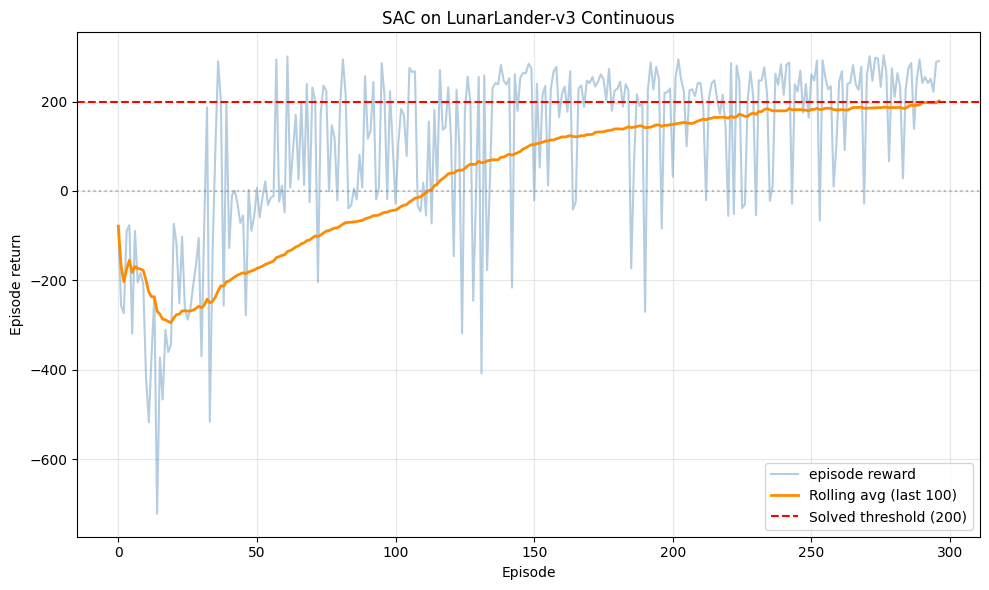

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(episode_rewards, color='steelblue', alpha=0.4, label='episode reward')
plt.plot(running_avg, color='darkorange', linewidth=2, label=f'Rolling avg (last {ROLLING_WINDOW})')
plt.axhline(y=solved_threshold, color='red', linestyle='--', label=f'Solved threshold ({solved_threshold})')         
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
plt.title('SAC on LunarLander-v3 Continuous')
plt.xlabel('Episode')
plt.ylabel('Episode return')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### **Evaluation Run 10 episodes**

Evaluation uses the actor directly, without exploration noise. SAC learns a deterministic policy, so evaluation is usually less noisy than training.

In [11]:
env = gym.make('LunarLander-v3', continuous=True)
test_rewards = []

for e_test in range(10):
    state, _ = env.reset()
    total_reward = 0.0

    for step in range(MAX_STEPS_PER_EPSISODE):
        # Deterministic evaluation: use the mean of the policy (no sampling noise).
        with torch.no_grad():
            state_t = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            mean, _ = actor(state_t)
            action = torch.tanh(mean).cpu().numpy().squeeze(0)

        next_state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        state = next_state
        if terminated or truncated:
            break

    test_rewards.append(total_reward)
    print(f"Test episode {e_test+1:2d}/10  Reward: {total_reward:+8.2f}  Steps: {step+1}")

env.close()
print(f"\nMean test reward: {np.mean(test_rewards):+.2f}  (std {np.std(test_rewards):.2f})")

Test episode  1/10  Reward:  +242.03  Steps: 429
Test episode  2/10  Reward:  +253.85  Steps: 288
Test episode  3/10  Reward:  +272.07  Steps: 352
Test episode  4/10  Reward:  +224.88  Steps: 385
Test episode  5/10  Reward:  +232.11  Steps: 391
Test episode  6/10  Reward:  +210.34  Steps: 471
Test episode  7/10  Reward:  +230.20  Steps: 338
Test episode  8/10  Reward:  +232.00  Steps: 342
Test episode  9/10  Reward:  +240.86  Steps: 327
Test episode 10/10  Reward:  +248.50  Steps: 286

Mean test reward: +238.68  (std 16.16)


#### **Render an episode as a GIF**


In [12]:
env = gym.make('LunarLander-v3', continuous=True, render_mode='rgb_array')
state, _ = env.reset()
frames = []
tot_rewards = 0.0

for step in range(MAX_STEPS_PER_EPSISODE):
    # Deterministic evaluation: use the mean of the policy (no sampling noise).
    with torch.no_grad():
        state_t = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        mean, _ = actor(state_t)
        action = torch.tanh(mean).cpu().numpy().squeeze(0)

    next_state, reward, terminated, truncated, _ = env.step(action)
    frames.append(env.render())
    tot_rewards += reward
    state = next_state

    if terminated or truncated:
        print(f"Episode reward: {tot_rewards:+.2f}  Steps: {step+1}")
        break

env.close()


def save_frames_as_gif(frames, path='./', filename='LunarLander_SAC_TORCH.gif'):
    images = [Image.fromarray(f) for f in frames]
    gif_path = os.path.join(path, filename)
    images[0].save(gif_path, save_all=True, append_images=images[1:],
                   duration=50, loop=0)
    print(f"Saved GIF to: {gif_path}")


save_frames_as_gif(frames)

Episode reward: +230.81  Steps: 297
Saved GIF to: ./LunarLander_SAC_TORCH.gif


#### **Takeaways and next steps**

**What SAC adds on top of TD3:**

1. **Stochastic squashed-Gaussian policy.** The actor outputs a distribution, not a single action. The tanh squash keeps actions in $[-1, 1]$ and the log-prob correction handles the change of variables.
2. **Entropy in the objective.** The critic target subtracts $\alpha \log \pi(a' \mid s')$, and the actor loss adds $\alpha \log \pi(\tilde a \mid s)$. This is what makes the algorithm "soft."
3. **No external exploration noise.** Exploration is built into the policy itself — sampling from $\pi(\cdot \mid s)$ naturally produces varied actions early in training.
4. **No delayed actor updates.** SAC typically updates the actor every step. The entropy term keeps the actor from overfitting to a noisy critic.

**What's still shared with TD3:**

- Twin critics with `min(Q_1, Q_2)` targets.
- Soft target updates (Polyak averaging).
- Off-policy replay buffer.

**What we deliberately left out** (and why you should know about it):

- **Auto-tuned $\alpha$.** In modern SAC, $\alpha$ is itself learned so the policy maintains a target entropy. This usually works much better than a fixed $\alpha$ — try `ALPHA = 0.05` or `ALPHA = 0.5` here and you'll see it matters.
- **Reward scaling.** Some implementations scale rewards to set $\alpha$'s effective magnitude. We skipped it.
- **N-step returns, prioritized replay, layer norm.** All useful in practice, none necessary to understand the algorithm.

**Try this:**

- Change `ALPHA` between 0.05 and 0.5 and watch the exploration behavior.
- Increase `TOTAL_STEPS` to 300_000 and you should reliably solve the environment.
- Compare with TD3 on the same env — SAC is usually more sample-efficient and less sensitive to hyperparameters.


In [14]:
import session_info
session_info.show(html=False)

-----
PIL                 12.1.0
gymnasium           1.2.2
matplotlib          3.10.8
numpy               2.4.2
session_info        v1.0.1
torch               2.11.0+cu130
-----
IPython             9.10.0
jupyter_client      8.8.0
jupyter_core        5.9.1
-----
Python 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
Linux-6.17.0-1018-nvidia-aarch64-with-glibc2.39
-----
Session information updated at 2026-05-22 18:59
